# Mlearn 510 - Lesson 02

# Predicting Fire Area Damage

### For this assignment, we will be using linear regresion to forecase fire area damage. We will leverage the [Forest Fires Data Set](https://archive.ics.uci.edu/ml/datasets/Forest+Fires) to solve this problem. Additional information regarding this work can be found [Cortez and Morais, 2007](http://www3.dsi.uminho.pt/pcortez/fires.pdf).

Attribute information:

   For more information, read [Cortez and Morais, 2007].

   1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
   2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
   3. month - month of the year: "jan" to "dec" 
   4. day - day of the week: "mon" to "sun"
   5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
   6. DMC - DMC index from the FWI system: 1.1 to 291.3 
   7. DC - DC index from the FWI system: 7.9 to 860.6 
   8. ISI - ISI index from the FWI system: 0.0 to 56.10
   9. temp - temperature in Celsius degrees: 2.2 to 33.30
   10. RH - relative humidity in %: 15.0 to 100
   11. wind - wind speed in km/h: 0.40 to 9.40 
   12. rain - outside rain in mm/m2 : 0.0 to 6.4 
   13. area - the burned area of the forest (in ha): 0.00 to 1090.84 
   (this output variable is very skewed towards 0.0, thus it may make
    sense to model with the logarithm transform). 

In [1]:
import pandas as pd
forestfires = pd.read_csv('forestfires.csv')
forestfires.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## Question 1.1: Using the [describe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html) method, provide the summary statistics of the data

In [2]:
forestfires.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


## Question 1.2: Apply log(area+1) to the data

In [3]:
import numpy as np
forestfires["log(area+1)"]=np.log10(forestfires["area"]+1)
forestfires.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,log(area+1)
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292,0.482512
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818,0.607333
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000,0.181844
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000,0.879096
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000,3.038159


## Question 2.1: Visually explore the data using pairplot.

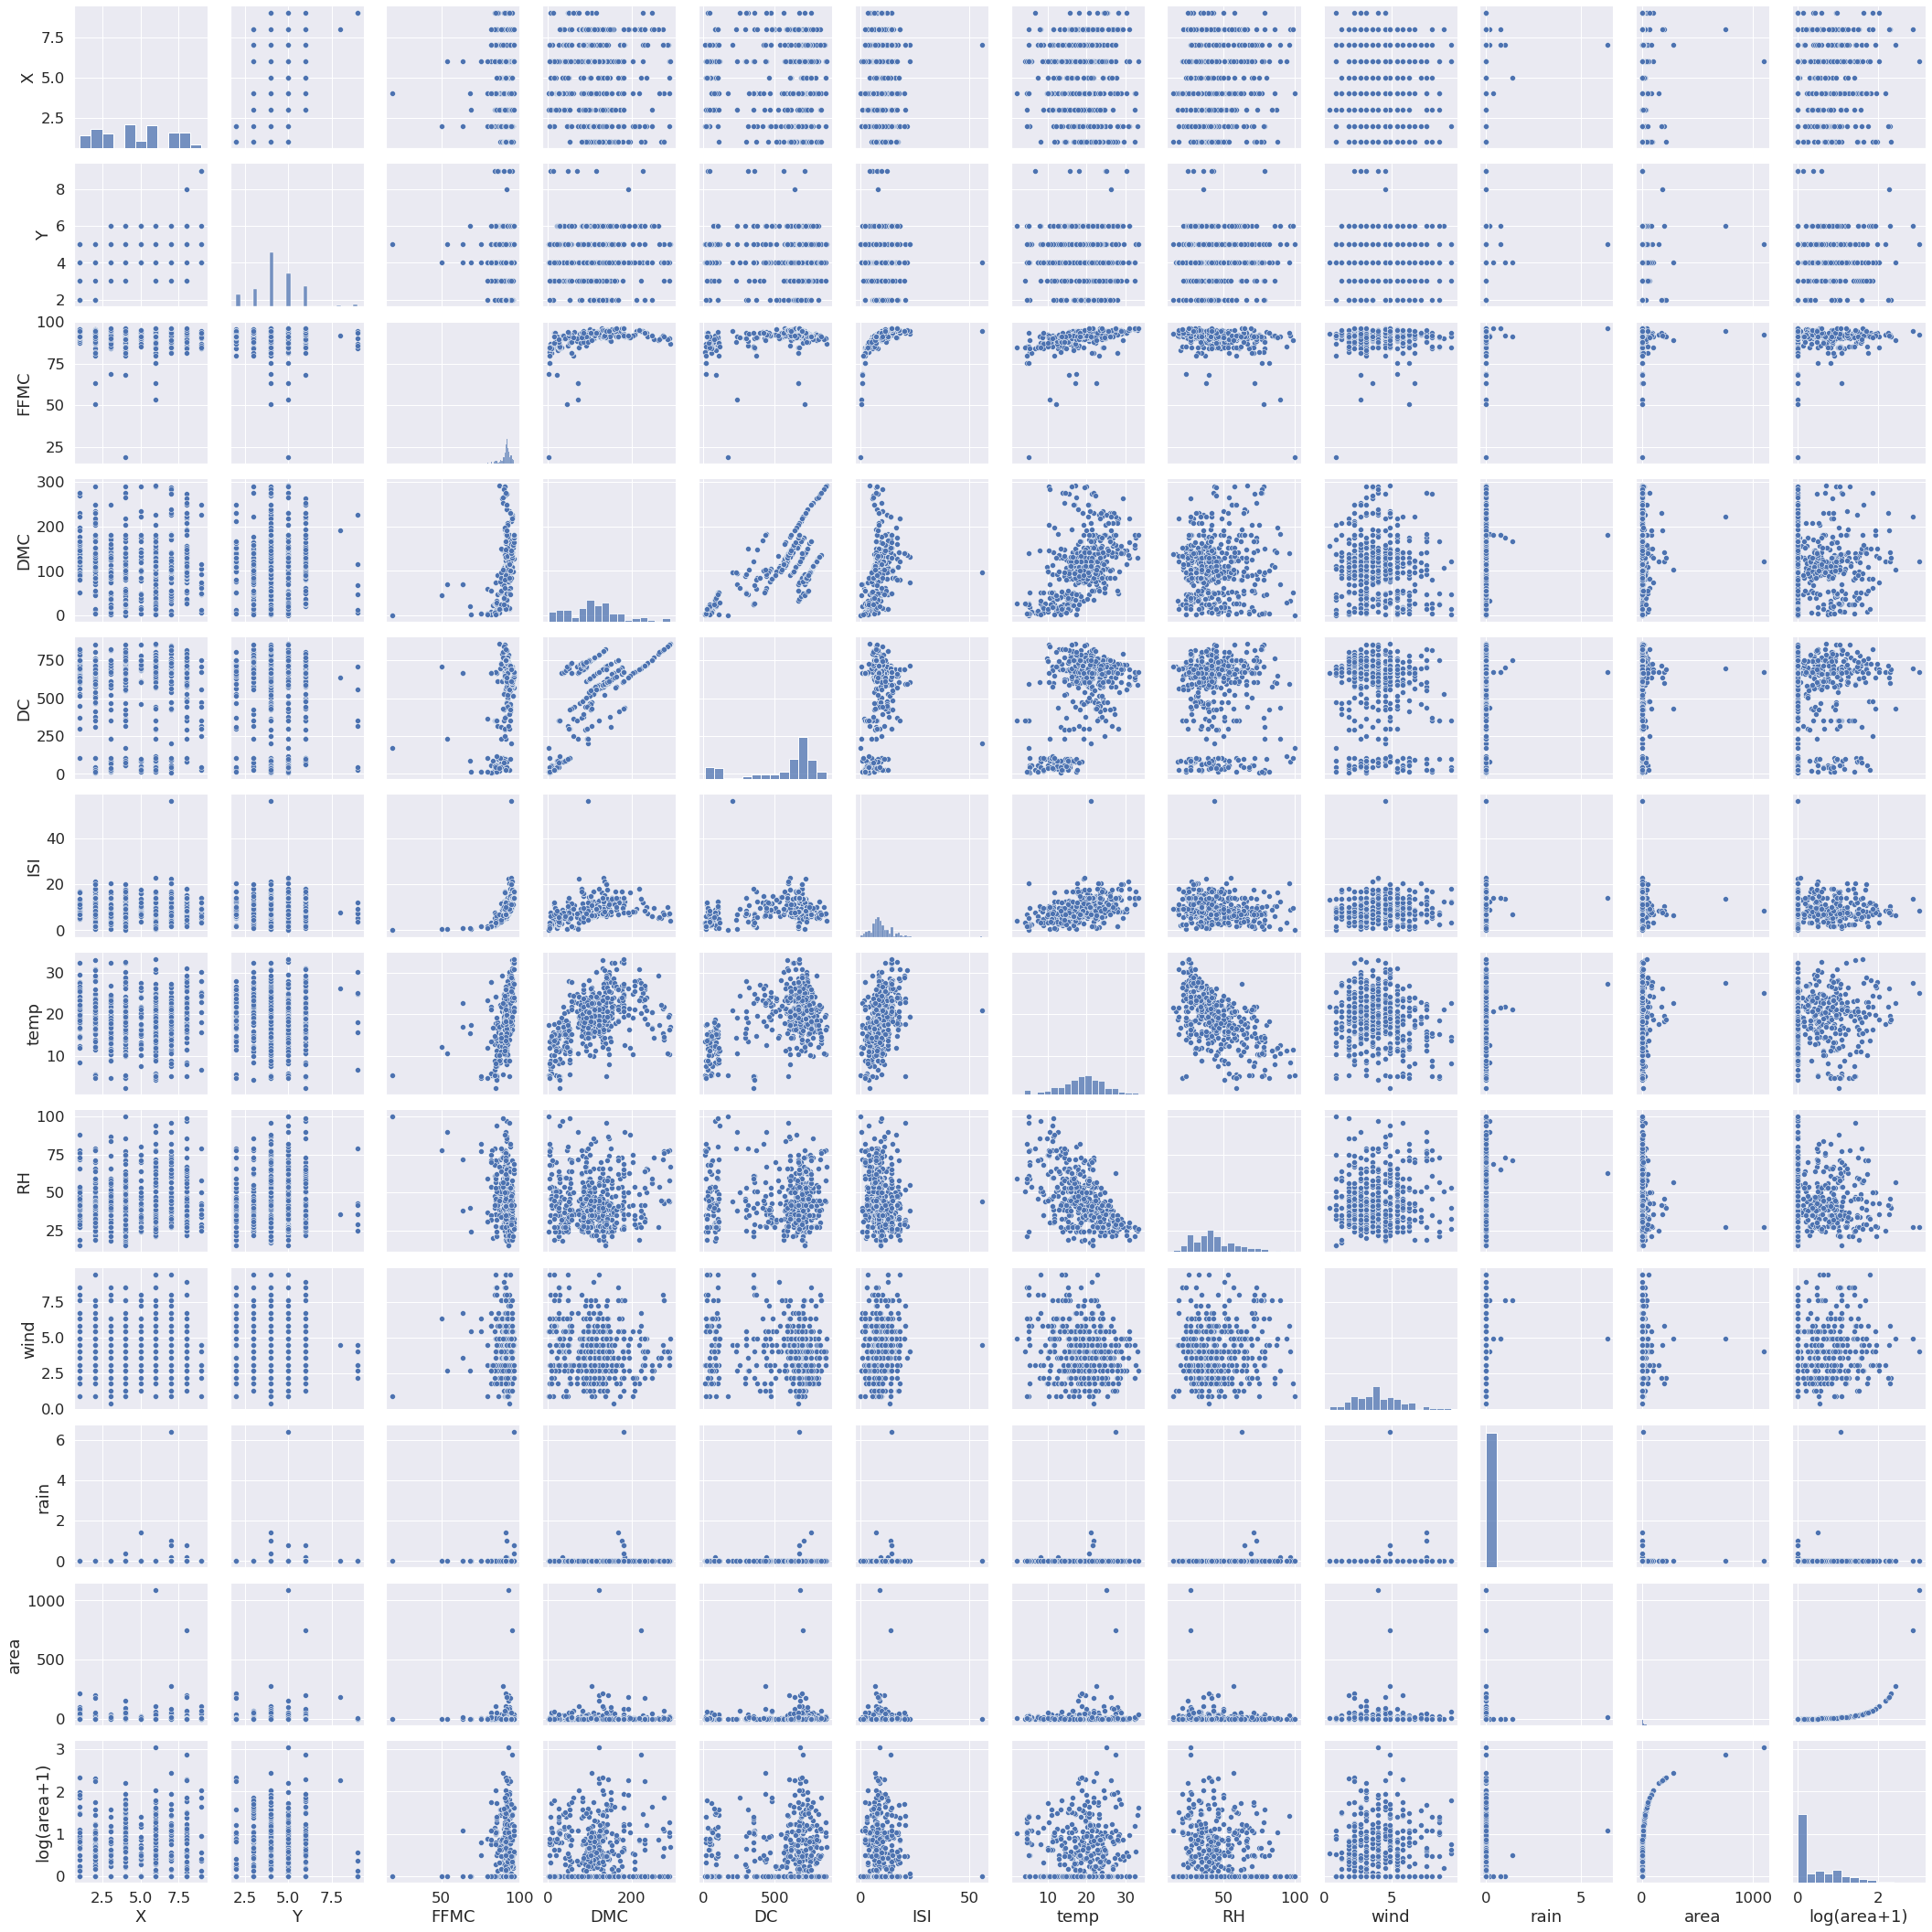

In [4]:
import seaborn as sns
sns.set(font_scale=1.5)
sns.pairplot(forestfires);

## Question 2.2: Zoom in at the rain vs area by plotting the scatter plot. What do you conclude?

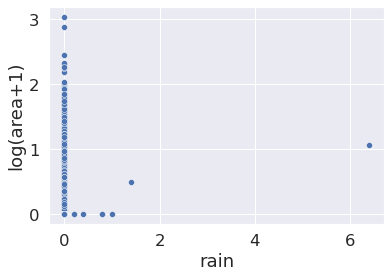

In [5]:
sns.scatterplot(data=forestfires, x="rain", y="log(area+1)");

### It seems that when it rains, the intensity of the forest fire (how much area is burned) is limited by an incredible degree, however, there's an substantial sampling bias here; the number of forest fire observations vastly outnumber the number of forest fire observations that occur while it's raining. If the more forest fire observations while raining are collected then a larger dataset can be formed and it can allow for a more confident claim about the trend. It's obvious why this is the case though, rain may be a uncommon event for this particular forest for example, or it may be that these fires occur during a "dry season" when there isn't much rain relative to other "wetter" times of the year. Lastly, there's a couple outlier points where there was a notable amount of forest burned while raining which can be eliminated by viewing only data points with rain lest than 1 mm.

Question 4.1: Develop a simple linear regression model, relating area with rain and wind only. Calculate the predict values based on test data.

Question 4.2: Calculate the mean squared error of predict results.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [7]:
forestfires1 = forestfires.drop(columns=["X","Y","month","day","FFMC","DC","DMC","ISI","temp","RH","area"])

In [10]:
X = np.asarray(forestfires1.drop(columns=["log(area+1)"]))
y = np.asarray(forestfires1["log(area+1)"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
reg = LinearRegression().fit(X_train, y_train)
y_true, y_pred = y_test, reg.predict(X_test)
print("mean squared error:",round(mean_squared_error(y_true,y_pred),4)*100,"%")

mean squared error: 35.35 %


Question 5.1: Develop a linear regression model, relating area with all features. Calculate the predict values based on test data.

Question 5.2: Calculate the mean squared error of predict results.

In [11]:
X = np.asarray(forestfires.drop(columns=["month","day","area","log(area+1)"]))
y = np.asarray(forestfires.drop(columns=["X","Y","month","day","FFMC","DC","DMC","ISI","temp","RH","area","rain","wind"]))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
reg = LinearRegression().fit(X_train, y_train)
y_true, y_pred = y_test, reg.predict(X_test)
print("mean squared error:",round(mean_squared_error(y_true,y_pred),4)*100,"%")

mean squared error: 33.2 %
